In [4]:
import pandas as pd
import numpy as np

In [6]:
data = pd.read_csv('student_dropout_dataset.csv')
data

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1
...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0
296,19,Male,14.24,0.00,Yes,0.1,Yes,0
297,20,Male,7.59,0.48,No,1.7,No,1
298,17,Female,14.57,0.00,Yes,4.1,Yes,0


In [8]:
data.isnull().sum()

age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64

In [10]:
def dectection_anomalies(df, target_col = None):
    df_temp = df.drop(columns= [target_col]) if target_col else df
    # vaaleurs manquantes
    valeurs_manquantes = df_temp.isnull().sum()
    # Détection des valeurs abérrantes
    outliers_info = {}
    # traitements des colonnes numérique
    col_num= df_temp.select_dtypes(include=[np.number]).columns
    for col in col_num:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1

        borne_inf = Q1- 1.5* IQR
        borne_sup = Q3 + 1.5*IQR
        # Identification des lignes abérrantes
        outliers = df_temp[(df_temp[col]<borne_inf) | (df_temp[col] > borne_sup)].shape[0]
        outliers_info[col] =outliers

    # synthèse des résultats
    synthese= pd.DataFrame({
        'valeurs manquantes' : valeurs_manquantes,
        'valeurs aberrantes' : pd.Series(outliers_info)
    }).fillna(0).astype(int)
    return synthese

In [12]:
res= dectection_anomalies(data, target_col ='dropout_risk' )
res

,valeurs manquantes,valeurs aberrantes
absenteeism_rate,0,0
age,0,0
average_grade,0,0
extra_activities,0,0
gender,0,0
internet_access,0,0
study_time_hours,0,0


Encodage des variables catégorielles


Analyse exploratoire des données

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               300 non-null    int64  
 1   gender            300 non-null    object 
 2   average_grade     300 non-null    float64
 3   absenteeism_rate  300 non-null    float64
 4   internet_access   300 non-null    object 
 5   study_time_hours  300 non-null    float64
 6   extra_activities  300 non-null    object 
 7   dropout_risk      300 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 18.9+ KB


In [18]:
data.describe()

,age,average_grade,absenteeism_rate,study_time_hours,dropout_risk
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,19.326667,11.600067,0.257633,2.516000,0.243333
std,2.873001,3.705599,0.138460,1.341321,0.429812
min,15.000000,5.030000,0.000000,0.000000,0.000000
25%,17.000000,8.440000,0.147500,1.400000,0.000000
50%,19.000000,11.755000,0.260000,2.600000,0.000000
75%,22.000000,14.640000,0.380000,3.525000,0.000000
max,24.000000,17.960000,0.500000,5.000000,1.000000


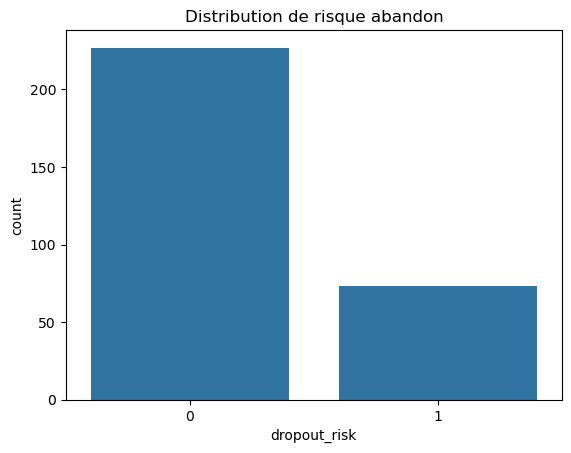

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='dropout_risk', data=data)
plt.title('Distribution de risque abandon')
plt.show()
    

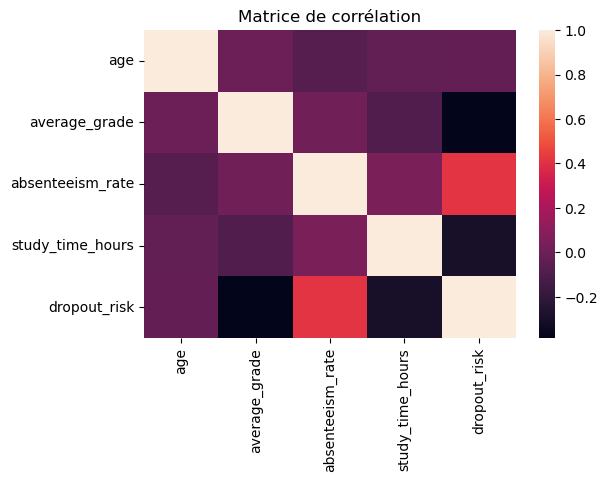

In [26]:
plt.figure(figsize=(6, 4))
sns.heatmap(data.select_dtypes(include=[np.number]).corr())
plt.title('Matrice de corrélation')
plt.show()

In [20]:
import math
def afficher_boxplot (df, target_col):
    #selection des variables numériques uniquement
    col_num= df.select_dtypes(include=['number']).columns.drop(target_col, errors='ignore')
    # Configuration de la grille (3 colonnes par ligne)
    n_cols= 3
    n_rows = math.ceil(len(col_num)/ n_cols)
    plt.figure(figsize=(15,5 *n_rows))
    # Boucle pour créer chaque graphique
    for i, col in enumerate(col_num):
        plt.subplot(n_rows, n_cols, i+1)
        sns.boxplot(x= target_col, y= col, data=df)
        plt.title(f'Distribution de {col}')
        plt.tight_layout()

    plt.show()


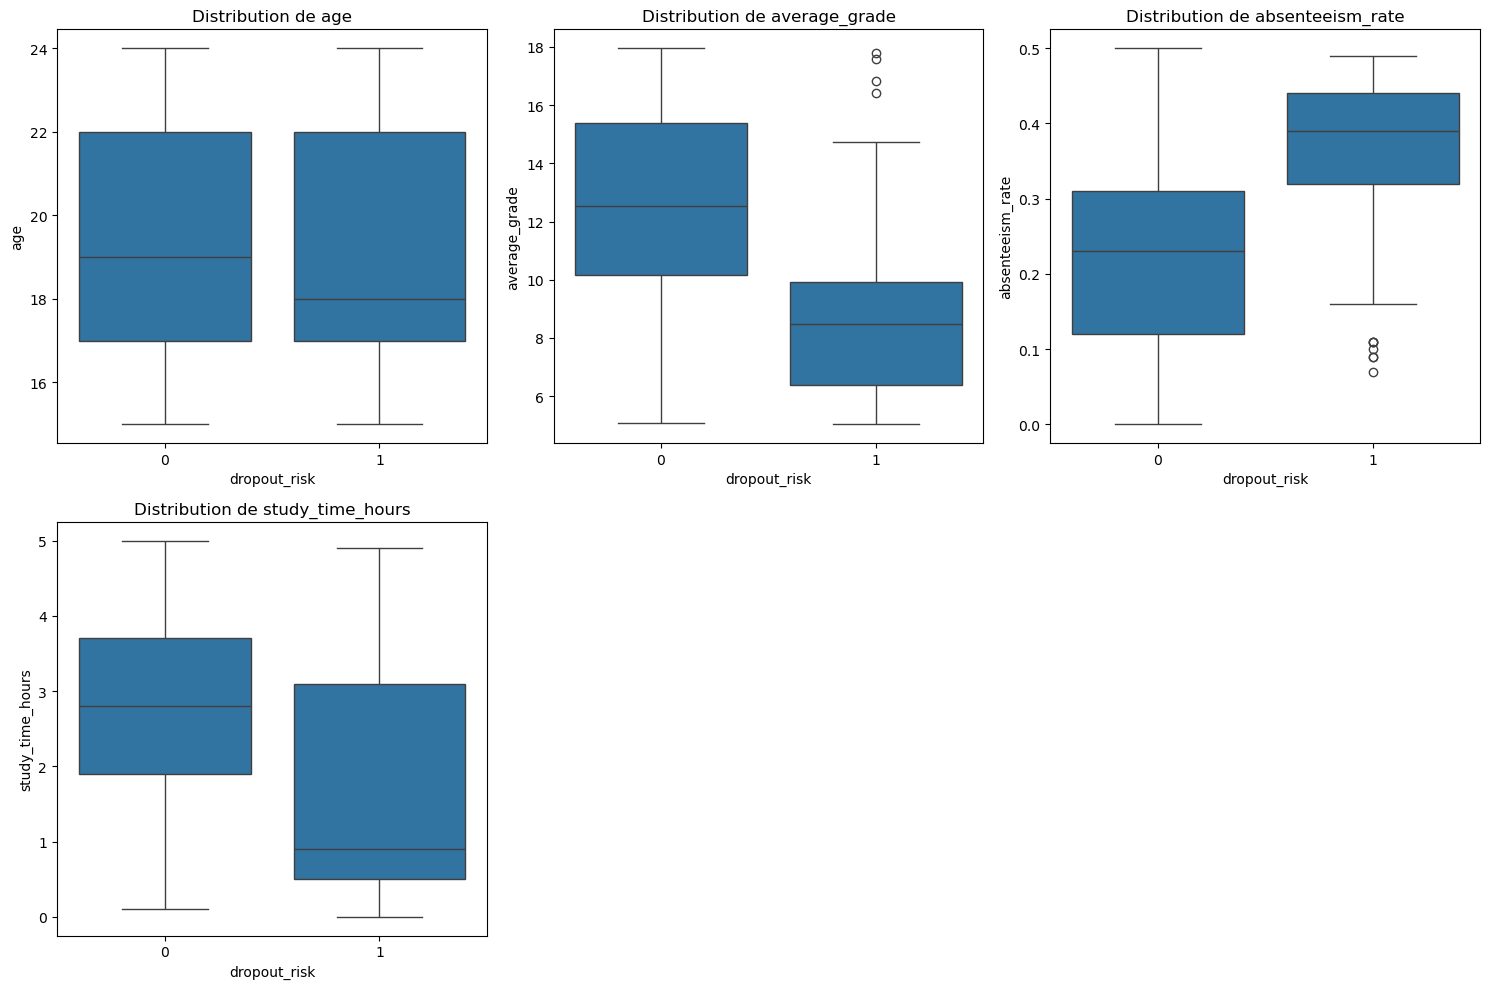

In [23]:
afficher_boxplot(data, target_col='dropout_risk')

les variables average_grade, absenteeism_rate et study_time_hours sont a des hauteurs différentes de la boite de la variable cible, ce que pourrait signifier que ces variables serait de bon predicteurs pour notre modèle. Ils pourront/ nous aiderons a expliqué notre variable cible.

# Features engineering

calcul du taux de présence

In [28]:
def engineering_taux_presence(df, col_absence, col_variable_x, nom_ratio) :
    # 1- calcul taux de présence
    df['taux_presence'] = 1 - df[col_absence]
    # création du ratio
    df[nom_ratio] = df[col_variable_x] / df['Taux_presence']
    return df

In [30]:
data['Taux_presence'] = 1 - data['absenteeism_rate']
data

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk,Taux_presence
0,21,Male,16.27,0.35,Yes,4.1,No,0,0.65
1,18,Female,12.30,0.38,No,0.2,No,1,0.62
2,22,Male,8.10,0.04,No,3.4,No,0,0.96
3,19,Male,13.84,0.25,No,4.8,Yes,0,0.75
4,21,Female,14.62,0.47,Yes,0.6,Yes,1,0.53
...,...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0,0.96
296,19,Male,14.24,0.00,Yes,0.1,Yes,0,1.00
297,20,Male,7.59,0.48,No,1.7,No,1,0.52
298,17,Female,14.57,0.00,Yes,4.1,Yes,0,1.00


In [32]:
data['Absence_pour_Ratio'] =data['absenteeism_rate'] .replace(0, 0.01)
data['Ratio Presence/Absence'] = (1 - data['absenteeism_rate']) /data['Absence_pour_Ratio']
data

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk,Taux_presence,Absence_pour_Ratio,Ratio Presence/Absence
0,21,Male,16.27,0.35,Yes,4.1,No,0,0.65,0.35,1.857143
1,18,Female,12.30,0.38,No,0.2,No,1,0.62,0.38,1.631579
2,22,Male,8.10,0.04,No,3.4,No,0,0.96,0.04,24.000000
3,19,Male,13.84,0.25,No,4.8,Yes,0,0.75,0.25,3.000000
4,21,Female,14.62,0.47,Yes,0.6,Yes,1,0.53,0.47,1.127660
...,...,...,...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0,0.96,0.04,24.000000
296,19,Male,14.24,0.00,Yes,0.1,Yes,0,1.00,0.01,100.000000
297,20,Male,7.59,0.48,No,1.7,No,1,0.52,0.48,1.083333
298,17,Female,14.57,0.00,Yes,4.1,Yes,0,1.00,0.01,100.000000


# Pourquoi cette technique
On considère que si l'absence est à 0, on la remplace par une valeur très petite(par 0.01). Cela évite d'avoir des ratios qui "explosent" et qui dominent tout nos modèle. un cas pratique, si on a un étudiant qui a 0% d'absence, son ratio sera de 1 000 000 avec l'epsilon. si un autre à 1% d'absence, son ratio sera à 99. Cet écart immense(1 million vs 99) va faire "perdre" notre modèle (notamment le svm).

# Interaction Absence x performance

POURQUOI : 
Un étudiant qui s'absente mais qui a d'excellentes notes n'est pas forcément en rique d'abandon, alors qu'un étudiant qui s'absente avec des notes faibles est en danger critique. 

In [37]:
data['Interaction_Moyenne_Absence'] = data['absenteeism_rate'] * (20 - data['average_grade'])
data

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk,Taux_presence,Absence_pour_Ratio,Ratio Presence/Absence,Interaction_Moyenne_Absence
0,21,Male,16.27,0.35,Yes,4.1,No,0,0.65,0.35,1.857143,1.3055
1,18,Female,12.30,0.38,No,0.2,No,1,0.62,0.38,1.631579,2.9260
2,22,Male,8.10,0.04,No,3.4,No,0,0.96,0.04,24.000000,0.4760
3,19,Male,13.84,0.25,No,4.8,Yes,0,0.75,0.25,3.000000,1.5400
4,21,Female,14.62,0.47,Yes,0.6,Yes,1,0.53,0.47,1.127660,2.5286
...,...,...,...,...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0,0.96,0.04,24.000000,0.0968
296,19,Male,14.24,0.00,Yes,0.1,Yes,0,1.00,0.01,100.000000,0.0000
297,20,Male,7.59,0.48,No,1.7,No,1,0.52,0.48,1.083333,5.9568
298,17,Female,14.57,0.00,Yes,4.1,Yes,0,1.00,0.01,100.000000,0.0000


identification des variables infuentes

In [40]:
def variables_influente_corr(df, target_col):
    df_num= df.select_dtypes(include=['number'])#.columns.drop(target_col, errors='ignore')
    # calcul de la corrélation avec la variabl cible
    matrice_corr = df_num.corr()
    correlations = matrice_corr[target_col].abs().sort_values(ascending= False)
    # On retire la target du classement
    classement=correlations.drop(labels=[target_col], errors='ignore')
    return classement

In [42]:
variables_influente_corr(data, 'dropout_risk')

Interaction_Moyenne_Absence    0.611439
Absence_pour_Ratio             0.412789
absenteeism_rate               0.412653
Taux_presence                  0.412653
average_grade                  0.384622
study_time_hours               0.297416
Ratio Presence/Absence         0.190551
age                            0.032086
Name: dropout_risk, dtype: float64

In [44]:
def encoder_variables_catégorielles(df, target_col):
    # Séparation de la target
    y = df[target_col]
    X = df.drop(columns = [target_col])
    # Identification des variables catégorielles
    cols_cat = X.select_dtypes(include = ['object','category']).columns.tolist()
    # Application du one-hot Encoding
    X_encoded = pd.get_dummies(X, columns = cols_cat, drop_first = True, dtype=int)
    # réassemblage avec la target
    df_final = pd.concat ([X_encoded, y], axis = 1)
    print (f"Encodage terminé.{len(cols_cat)} colonnes transformées.")
    return df_final

In [46]:
df_clean = encoder_variables_catégorielles(data, target_col ='dropout_risk')

Encodage terminé.3 colonnes transformées.


In [48]:
df_clean

,age,average_grade,absenteeism_rate,study_time_hours,Taux_presence,Absence_pour_Ratio,Ratio Presence/Absence,Interaction_Moyenne_Absence,gender_Male,internet_access_Yes,extra_activities_Yes,dropout_risk
0,21,16.27,0.35,4.1,0.65,0.35,1.857143,1.3055,1,1,0,0
1,18,12.30,0.38,0.2,0.62,0.38,1.631579,2.9260,0,0,0,1
2,22,8.10,0.04,3.4,0.96,0.04,24.000000,0.4760,1,0,0,0
3,19,13.84,0.25,4.8,0.75,0.25,3.000000,1.5400,1,0,1,0
4,21,14.62,0.47,0.6,0.53,0.47,1.127660,2.5286,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
295,15,17.58,0.04,3.6,0.96,0.04,24.000000,0.0968,0,1,0,0
296,19,14.24,0.00,0.1,1.00,0.01,100.000000,0.0000,1,1,1,0
297,20,7.59,0.48,1.7,0.52,0.48,1.083333,5.9568,1,0,0,1
298,17,14.57,0.00,4.1,1.00,0.01,100.000000,0.0000,0,1,1,0


gender:
Mâle -> true -> 1
femelle -> false ->0

internet_access:
yes -> true ->1
no -> false ->0

extra_activities:
yes -> true ->1
no -> false ->0

# Normalisation des variales

In [54]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler = StandardScaler()
# application du scaler sur les features
target_col = 'dropout_risk'
X_scaled = scaler.fit_transform(df_clean.drop(columns = [target_col]))



In [58]:
from sklearn.model_selection import train_test_split
X = X_scaled
y = df_clean[target_col]

In [60]:
X_train, X_temp, y_train, y_temp =train_test_split(X,y, test_size=0.3, random_state = 42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = (1/3), random_state = 42)

print(f" entrainement: { X_train.shape[0]} lignes")
print (f" test: {X_test.shape[0]} lignes ")
print (f" val: {X_val.shape[0]} lignes")

 entrainement: 210 lignes
 test: 60 lignes 
 val: 30 lignes


C:\Users\alexa\anaconda3\envs\DeepLearning_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:46:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


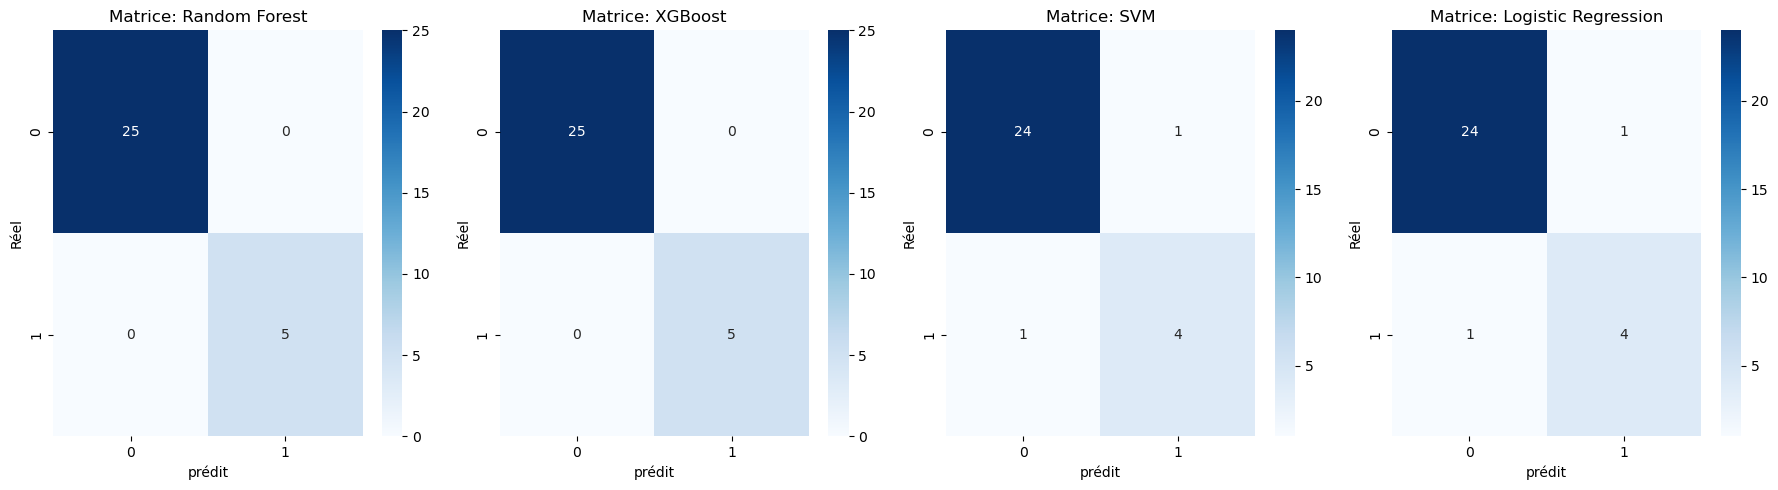


--- Tableau Comparatif des performances ---
             Modèle  Accuracy  precision   Recall  F1-score
      Random Forest  1.000000   1.000000 1.000000  1.000000
            XGBoost  1.000000   1.000000 1.000000  1.000000
                SVM  0.933333   0.933333 0.933333  0.933333
Logistic Regression  0.933333   0.933333 0.933333  0.933333


In [68]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

modeles = {
    "Random Forest" : RandomForestClassifier(random_state=42),
    "XGBoost" : XGBClassifier(use_label_encoder = False, eval_metric = 'logloss', random_state=42),
    "SVM" : SVC(probability= True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}
# Dictionnaire pour stocker les résultas 
resultats_metrics = []
# Matrice de confusion
fig, axes = plt.subplots(1,4, figsize=(18,5))
for i, (nom, model) in enumerate(modeles.items()):
    # Entrainement des modèles
    model.fit(X_train, y_train)
    # Prediction
    y_pred = model.predict(X_val)
    # calcul des métriques
    metrics = {
    "Modèle": nom,
    "Accuracy": accuracy_score(y_val, y_pred),
    "precision": precision_score (y_val, y_pred, average='weighted'),
    "Recall": recall_score(y_val, y_pred, average='weighted'),
    "F1-score": f1_score(y_val, y_pred, average='weighted')
    }
    resultats_metrics.append(metrics)
    # Matrice de confusion
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot = True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f"Matrice: {nom}")
    axes[i].set_xlabel("prédit")
    axes[i].set_ylabel("Réel")

# affichage du tableau recap
df_resultats = pd.DataFrame(resultats_metrics)
plt.tight_layout()
plt.show()

print("\n--- Tableau Comparatif des performances ---")
print (df_resultats.to_string(index=False))

# Verification de risque de surapprentissage

In [73]:
comparaison_overfitting = []
for nom, model in modeles.items():
    # score sur l'entrainement
    score_train = model.score(X_train, y_train)
    #score sur la validation
    score_val = model.score(X_val, y_val)
    comparaison_overfitting.append({
        "Modèle": nom,
        "Score train(Acc)":round(score_train, 3),
        "score val (Acc)": round(score_val, 3),
        "Ecart(Gap)": round(score_train - score_val, 3)
    })
df_overfit = pd.DataFrame(comparaison_overfitting)
print(df_overfit)


                Modèle  Score train(Acc)  score val (Acc)  Ecart(Gap)
0        Random Forest             1.000            1.000       0.000
1              XGBoost             1.000            1.000       0.000
2                  SVM             0.943            0.933       0.010
3  Logistic Regression             0.910            0.933      -0.024


# Evaluation sur le jeu de données test

In [76]:
# Evaluation sur le jeu test
resultats_test = []
for nom, model in modeles.items():
    y_pred_test = model.predict(X_test)
    resultats_test.append({
    "Modèle": nom,
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "precision": precision_score (y_test, y_pred_test, average='weighted'),
    "Recall": recall_score(y_test, y_pred_test, average='weighted'),
    "F1-score": f1_score(y_test, y_pred_test, average='weighted')
    })
df_final_test = pd.DataFrame(resultats_test)
print("----Score final dur le jeu de test----")
print(df_final_test)
    

----Score final dur le jeu de test----
                Modèle  Accuracy  precision    Recall  F1-score
0        Random Forest  0.950000   0.949306  0.950000  0.949263
1              XGBoost  0.983333   0.983681  0.983333  0.983088
2                  SVM  0.883333   0.880556  0.883333  0.881614
3  Logistic Regression  0.833333   0.833333  0.833333  0.833333


# Optimisation des modèles avec le Grid Search( pour rechercher les meilleurs hyperparamètre qui pourront maximiser notre score)

In [79]:
from sklearn.model_selection import GridSearchCV
# 1- paramètres pour le Random Forest
param_rf ={
    'n_estimators': [100, 200],
    'max_depth': [10,20, None],
    'min_samples_split': [2,5]
}
# 2- paramètres pour XGBoost
param_xgb = {
    'n_estimators':[100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6]
}
# 3- Paramètres pour SVM
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'poly', 'sigmoid']
}
# 4- paramètre pour la regression Logistic
param_lr = {
    'C': [0.01, 0.1,1,10,100],
    'solver':['lbfgs', 'liblinear']
}
    

# Dictionnaire de configuration
grid_configs = [
    ("Random  Forest", RandomForestClassifier(random_state=42), param_rf),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric = 'logloss', random_state=42), param_xgb),
    ("SVM", SVC(random_state=42), param_svm),
    ("Logistic Regression", LogisticRegression(max_iter = 1000, random_state=42), param_lr)
]

meilleurs_modeles ={}
for nom, model, params in grid_configs:
    print(f"Optimisation de {nom}...")
    grid = GridSearchCV(model,params, cv=10, scoring = 'f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    meilleurs_modeles[nom] = grid.best_estimator_
    print(f"Meilleurs paramètres: {grid.best_params_}")
    

Optimisation de Random  Forest...
Meilleurs paramètres: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Optimisation de XGBoost...


C:\Users\alexa\anaconda3\envs\DeepLearning_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:55:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Optimisation de SVM...
Meilleurs paramètres: {'C': 1, 'kernel': 'rbf'}
Optimisation de Logistic Regression...
Meilleurs paramètres: {'C': 0.1, 'solver': 'liblinear'}


In [81]:
# Test sur les données optimisées avec les meilleurs paramètres
Resultats_optimisés = []
for nom, model in meilleurs_modeles.items():
    y_pred_final = model.predict(X_test)
    Resultats_optimisés.append({
    "Modele": nom,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "precision": precision_score (y_test, y_pred_final, average='weighted'),
    "Recall": recall_score(y_test, y_pred_final, average='weighted'),
    "F1-score": f1_score(y_test, y_pred_final, average='weighted')
    })
df_final_opti = pd.DataFrame(Resultats_optimisés)
print("\n--- Résultats après GRIDSEARCH SUR LE TEST ---")
print(df_final_opti)
    


--- Résultats après GRIDSEARCH SUR LE TEST ---
                Modele  Accuracy  precision    Recall  F1-score
0       Random  Forest  0.950000   0.949306  0.950000  0.949263
1              XGBoost  0.983333   0.983681  0.983333  0.983088
2                  SVM  0.883333   0.880556  0.883333  0.881614
3  Logistic Regression  0.816667   0.821998  0.816667  0.819076


# Verification du meilleur compromis biais variance sur les train et le val

In [84]:
resultats_compromis = []
for nom, model in meilleurs_modeles.items():
    score_train = model.score(X_train, y_train)
    score_val = model.score(X_val, y_val)
    resultats_compromis. append({
    "Modèle": nom,
    "Train Score" : round(score_train, 4),
    "val sore" : round(score_val, 4),
    "Ecart(Gap)" : round(score_train - score_val, 4)
    })

df_compromis = pd.DataFrame(resultats_compromis)
print("---- Analyse Biais-Variance (Après optimisation) ----")
print(df_compromis )

---- Analyse Biais-Variance (Après optimisation) ----
                Modèle  Train Score  val sore  Ecart(Gap)
0       Random  Forest       1.0000    1.0000      0.0000
1              XGBoost       1.0000    1.0000      0.0000
2                  SVM       0.9429    0.9333      0.0095
3  Logistic Regression       0.9190    0.9333     -0.0143


Nous ferons le choix de garder le modèle XGBoost comme meilleur modèle.
Sur les données de test, le modèle XGBoost à les meilleurs performances. 


# AUC ET MATRICE DE CONFUSION DU MODELE XGBoost FINAL

-----Evaluation final SVM -----
Score AUC: 1.0000
F1-Score: 0.9831


<Figure size 800x600 with 0 Axes>

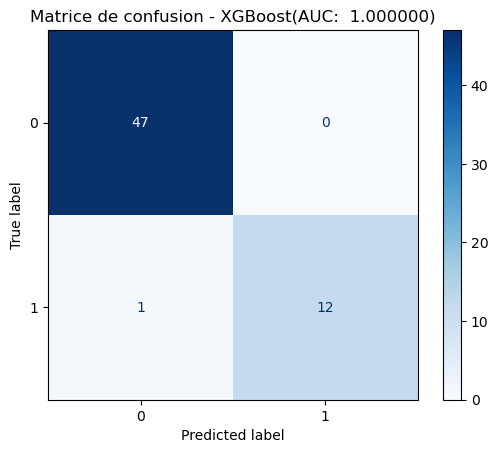

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve
# 1- predictions avec le meilleur modèle SVM optimisé
meilleur_XGBoost = meilleurs_modeles['XGBoost']
y_pred_XGBoost = meilleur_XGBoost .predict(X_test)
y_prob_XGBoost = meilleur_XGBoost.predict_proba(X_test) [:,1]


# 2- Calcul de l"AUC
  #y_score_svm = meilleur_svm.decision_function(X_test)
auc_score = roc_auc_score(y_test, y_prob_XGBoost)

# Affichage de resultats
print(f"-----Evaluation final SVM -----")
print(f"Score AUC: {auc_score:.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_XGBoost, average='weighted'):.4f}")

# Matrice de confusion 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_XGBoost)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= meilleur_XGBoost.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matrice de confusion - XGBoost(AUC: {auc_score: 2f})")
plt.show()
                      

In [100]:
import joblib 
joblib.dump( meilleurs_modeles['XGBoost'],'modele_XGBoost_abandon.pkl')

print(f"Fichier créé avec succès dans le dossier!")


Fichier créé avec succès dans le dossier!


In [104]:
try:
    joblib.dump(meilleurs_modeles['XGBoost'], 'scaler_XGBoost.pkl')
    joblib.dump(scaler, 'mon_scaler.pkl')
    print ("succès: les fichers 'scaler_XGBoost' et 'mon scaler'ont été enregistrés")
except KeyError :
    print("Erreur")
# Vérification
import os
if 'scaler_XGBoost.pkl' in os.listdir():
    print("le fichier est bien présent")
    

succès: les fichers 'scaler_XGBoost' et 'mon scaler'ont été enregistrés
le fichier est bien présent
